# 04. Agrupamiento de empresas - Fashion Transparency Index 2023

### Objetivo del notebook

Identificar perfiles de transparencia corporativa entre las empresas analizadas mediante técnicas de agrupamiento no supervisado, utilizando la matriz empresa–indicador construida a partir de los indicadores binarios del Fashion Transparency Index 2023.

### Descripción general

En esta etapa se compararon distintos métodos de agrupamiento con el propósito de identificar grupos de empresas que presenten patrones similares de divulgación. Como punto de partida, se evaluaron **K-Means** y **clustering jerárquico**.

El número de grupos se exploró mediante criterios cuantitativos como el **método del codo (Elbow Method)** y el **coeficiente de Silhouette**. Asimismo, se revisó la estabilidad de los resultados ante distintas configuraciones de los algoritmos y se realizó una interpretación de los perfiles obtenidos a partir de sus patrones de divulgación.

La selección final del método y del número de clusters consideró tanto los resultados cuantitativos como la capacidad de los grupos identificados para representar perfiles de transparencia diferenciados e interpretables.

In [ ]:
# Importamos las librerías necesarias

# Manipulación y análisis de datos
import pandas as pd
import numpy as np
from pathlib import Path

# Formato de texto
import textwrap

# Visualización
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering

# Evaluación de clusters y estabilidad
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Clustering jerárquico
from scipy.cluster.hierarchy import linkage, dendrogram


# Configuración general de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


# Definimos una semilla para asegurar que los resultados
# puedan reproducirse al volver a ejecutar el notebook
SEMILLA = 22

# Definimos las rutas principales del proyecto
ruta_proyecto = Path(
    "/Users/avrilsalazar/Documents/FashionTransparency2023"
)

ruta_datos = ruta_proyecto / "processed"
ruta_figuras = ruta_proyecto / "docs"


# Verificamos que la carpeta de datos procesados exista
if not ruta_datos.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de datos procesados: {ruta_datos}"
    )

# Creamos la carpeta de figuras si todavía no existe
ruta_figuras.mkdir(
    parents=True,
    exist_ok=True
)

print("Rutas del proyecto configuradas correctamente.")


# Definimos la misma paleta utilizada en el análisis exploratorio
AZUL_MARINO = "#17324D"
AZUL_SECUNDARIO = "#506B84"
GRIS_OSCURO = "#4A4A4A"
GRIS_MEDIO = "#A7ADB4"
GRIS_CLARO = "#E6E9ED"
NEGRO = "#1A1A1A"


# Establecemos la misma configuración visual utilizada
# en las figuras del análisis exploratorio
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRIS_MEDIO,
    "axes.labelcolor": NEGRO,
    "axes.titlecolor": NEGRO,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": GRIS_OSCURO,
    "ytick.color": GRIS_OSCURO,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10
})

Rutas del proyecto configuradas correctamente.


In [3]:
# Función para guardar las figuras del análisis

def guardar_figura(fig, nombre_archivo):
    """
    Guarda una figura en alta resolución dentro de la carpeta docs.
    """

    fig.savefig(
        ruta_figuras / f"{nombre_archivo}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

### Preparación de la matriz para el agrupamiento

La matriz utilizada para el análisis contiene **250 empresas y 109 indicadores binarios de transparencia**. Cada fila representa una empresa y cada columna corresponde a un indicador del Fashion Transparency Index 2023, codificado como **1 cuando la empresa divulga la información evaluada y 0 cuando no la divulga**.

Antes de iniciar el agrupamiento, se verifica nuevamente que la matriz no contenga valores faltantes y que todos los indicadores conserven la codificación binaria esperada. Estas comprobaciones permiten asegurar que la información utilizada en los modelos corresponde a la matriz validada durante la etapa de limpieza y selección de variables.

In [4]:
# Cargamos la matriz empresa-indicador construida
# en la etapa de limpieza y selección de variables

matriz = pd.read_csv(
    ruta_datos / "matriz_empresas_clustering.csv"
)

display(matriz.head())

,Company,Pais_sede,Fashion Revolution+1.5 Verified Sustainability Report,Fashion Revolution+Accountable Board Member Identified,Fashion Revolution+Affected Stakeholder Engagement in Remediation,Fashion Revolution+Approach to Defining Sustainable Materials,Fashion Revolution+Approach to Involving Women in Human Rights Due Diligence,Fashion Revolution+Commitment to Degrowth,Fashion Revolution+Commitment to Eliminate Hazardous Chemicals,Fashion Revolution+Decarbonisation Commitment,Fashion Revolution+Decarbonisation Progress,Fashion Revolution+Describes Environmental Due Diligence Process,Fashion Revolution+Describes Human Rights Due Diligence Process,Fashion Revolution+Discloses % of Circular Products,Fashion Revolution+Discloses Annual Investment in Decarbonisation,Fashion Revolution+Discloses Approach to Living Wage,Fashion Revolution+Discloses Approach to Recruitment Fees,Fashion Revolution+Discloses Breakdown of Reuse/Recyling of Pre-consumer Waste,Fashion Revolution+Discloses Coal Use,"Fashion Revolution+Discloses Content of Scope 1, 2 and 3 Emissions",Fashion Revolution+Discloses Data on Modern Slavery Prevalence,Fashion Revolution+Discloses Efforts to Invest in Supply Chain Workers,Fashion Revolution+Discloses Evidence of Developing Circular Solutions,Fashion Revolution+Discloses Free on Board (FOB) Price Changes (COVID-19 Response),Fashion Revolution+Discloses Gender Equality Actions in Supplier Facilities,Fashion Revolution+Discloses Living Wage Estimates Used for Benchmarking,Fashion Revolution+Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum,Fashion Revolution+Discloses Number of Workers Affected by Recruitment Fees,Fashion Revolution+Discloses Percentage of Workers Paid By Piece Rate,Fashion Revolution+Discloses Percentage of Workers Receiving Wage Payments Digitally,Fashion Revolution+Discloses Policy on Up-Front Supplier Payments,Fashion Revolution+Discloses Prevalance of Collective Bargaining Violations,Fashion Revolution+Discloses Progress on Sustainable Materials Strategy,Fashion Revolution+Discloses Progress to Eliminate Hazardous Chemicals,Fashion Revolution+Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels,Fashion Revolution+Discloses Progress to Reducing Virgin Plastics,Fashion Revolution+Discloses Progress toward the payment of a Living Wage to workers in the supply chain,Fashion Revolution+Discloses Proportion of Workers Paid Minimum Wage,Fashion Revolution+Discloses Quantity of Orders Changed After Original Agreement,Fashion Revolution+Discloses Quantity of Orders with Labor Cost Protection,Fashion Revolution+Discloses Quantity of Post-production Waste Generated,Fashion Revolution+Discloses Quantity of Pre-Production Waste Generated,Fashion Revolution+Discloses Quantity of Products Destroyed,Fashion Revolution+Discloses Quantity of Products Produced,Fashion Revolution+Discloses Sourced Fibre Breakdown,Fashion Revolution+Discloses Strategy to Achieving Living Wage,Fashion Revolution+Discloses Take-back Scheme Outcomes,Fashion Revolution+Discloses Time Taken to Pay Purchase Orders,Fashion Revolution+Discloses Water-Related Risk Assessment Process,Fashion Revolution+Discloses number or % of Workers covered by Collective Bargaining Agreements,"Fashion Revolution+Discloses number or % of supplier facilities that have independent, democratically elected trade unions",Fashion Revolution+Employee Incentives to Improve Impacts,Fashion Revolution+Environmental Profit and Loss Statement,Fashion Revolution+Environmental Risk Prevention and Remediation Outcomes Published,Fashion Revolution+Environmental Risks Impacts and Violations Identified,Fashion Revolution+Executive Incentives to Improve Impacts,Fashion Revolution+Executive Pay Linked to Environmental and Social Targets,Fashion Revolution+Exit Strategy,Fashion Revolution+Grievance Mechanism - Direct Employees,Fashion Revolution+Grievance Mechanism - Supply Chain Workers,Fashion Revolution+Grievance Me

Las variables **Company** y **Pais_sede** se conservan únicamente como información descriptiva para identificar e interpretar posteriormente a las empresas. Por lo tanto, ninguna de estas variables se utiliza como entrada para la formación de los clusters.

In [5]:
# Separamos la información descriptiva de las variables
# que serán utilizadas para el agrupamiento

informacion_empresas = matriz[
    ["Company", "Pais_sede"]
].copy()

X = matriz.drop(
    columns=["Company", "Pais_sede"]
)

print(f"Número de empresas: {X.shape[0]}")
print(f"Número de indicadores: {X.shape[1]}")

Número de empresas: 250
Número de indicadores: 109


In [6]:
# Verificamos los tipos de dato

print("Tipos de dato:")
display(X.dtypes.value_counts())

# Verificamos que no existan valores faltantes

print(
    "Valores faltantes:",
    X.isna().sum().sum()
)

# Verificamos que los indicadores conserven
# únicamente la codificación binaria 0/1

valores_matriz = sorted(
    pd.unique(X.to_numpy().ravel())
)

print(
    "Valores presentes en la matriz:",
    valores_matriz
)

Tipos de dato:


int64    109
Name: count, dtype: int64

Valores faltantes: 0
Valores presentes en la matriz: [0, 1]


## K-Means

El primer método evaluado es **K-Means**, un algoritmo de agrupamiento no supervisado que divide las observaciones en un número previamente definido de grupos o *clusters*. El método busca que las empresas pertenecientes a un mismo grupo sean lo más similares posible entre sí y que existan diferencias entre los grupos identificados.

Cada cluster se encuentra representado por un **centroide**, que corresponde al promedio de las observaciones que forman parte del grupo. Debido a que los indicadores utilizados en este análisis están codificados como 0 y 1, los valores de los centroides pueden interpretarse como la proporción promedio de divulgación de cada indicador dentro del cluster.

Una decisión necesaria en K-Means es determinar el número de clusters que se utilizará. Debido a que este número no se conoce previamente, se evalúan distintas configuraciones de **k**, donde *k* representa el número de grupos en los que se dividirán las empresas.

Para explorar un número adecuado de clusters se utilizan dos criterios. El primero es el **método del codo (Elbow Method)**, basado en la inercia del modelo. La inercia representa la suma de las distancias cuadradas entre las observaciones y el centroide del cluster al que pertenecen. A medida que aumenta el número de clusters, la inercia disminuye; por ello, el método del codo busca identificar el punto a partir del cual agregar nuevos grupos produce mejoras cada vez menores.

El segundo criterio es el **coeficiente de Silhouette**, que evalúa simultáneamente qué tan similares son las empresas dentro de un mismo cluster y qué tan separadas se encuentran de los demás clusters. El coeficiente toma valores entre -1 y 1, donde valores mayores indican, en términos generales, grupos más cohesionados y mejor separados entre sí.

Estos criterios no se utilizan de manera aislada para seleccionar el modelo final. Sus resultados permiten identificar configuraciones candidatas que posteriormente serán comparadas considerando también la estabilidad de los agrupamientos y la capacidad de los perfiles obtenidos para representar patrones de divulgación.

### Evaluación del número de clusters

Para explorar el número de clusters más adecuado, se evalúan configuraciones de **k = 1 a k = 10**. Para cada configuración se registra la inercia del modelo y, a partir de dos clusters, el coeficiente de Silhouette. Estos resultados se utilizan posteriormente para comparar las configuraciones mediante el método del codo y el coeficiente de Silhouette.

In [7]:
# Evaluamos distintas configuraciones de K-Means para explorar
# qué número de clusters podría representar mejor la estructura de los datos.

# Creamos una lista vacía donde iremos guardando los resultados
# obtenidos para cada número de clusters evaluado
resultados_kmeans = []

# Probamos valores de k desde 1 hasta 10
# En K-Means, k representa el número de clusters que queremos formar
# range(1, 11) genera los valores:
# 1, 2, 3, ..., 10.
for k in range(1, 11):

    # Creamos un modelo K-Means para el número de clusters
    # correspondiente a la iteración actual
    modelo = KMeans(

        # Indicamos cuántos clusters debe formar el modelo
        n_clusters=k,

        # Fijamos una semilla para que los resultados puedan
        # reproducirse al volver a ejecutar el notebook
        random_state=SEMILLA,

        # K-Means depende de la posición inicial de los centroides.
        # Con n_init=20 el algoritmo se ejecuta 20 veces utilizando
        # diferentes inicializaciones y conserva la mejor solución.
        n_init=20
    )

    # Ajustamos el modelo utilizando los 109 indicadores binarios
    # de las 250 empresas.
    
    # fit_predict realiza dos operaciones:
    # 1. ajusta el modelo a los datos;
    # 2. devuelve el cluster asignado a cada empresa
    etiquetas = modelo.fit_predict(X)

    # Recuperamos la inercia del modelo
    # La inercia corresponde a la suma de las distancias cuadradas
    # entre cada empresa y el centroide del cluster al que pertenece
    # Este valor será utilizado posteriormente para construir
    # la gráfica del método del codo
    inercia = modelo.inertia_

    # El coeficiente de Silhouette solamente puede calcularse
    # cuando existen al menos dos clusters
    if k >= 2:

        # Calculamos el coeficiente de Silhouette utilizando:
        # X = los indicadores de las empresas;
        # etiquetas = el cluster asignado a cada empresa
        silhouette = silhouette_score(
            X,
            etiquetas
        )

    else:

        # Para k = 1 no es posible calcular Silhouette,
        # porque todas las empresas pertenecen al mismo grupo
        # y no existe otro cluster con el cual comparar su separación.
        # Por ello registramos un valor faltante (NaN).
        silhouette = np.nan

    # Guardamos los resultados obtenidos para esta configuración
    # antes de pasar al siguiente valor de k.
    resultados_kmeans.append({

        # Número de clusters evaluado.
        "Clusters": k,

        # Inercia obtenida por el modelo.
        "Inercia": inercia,

        # Coeficiente de Silhouette obtenido.
        "Silhouette": silhouette
    })

# Una vez evaluados todos los valores de k,
# convertimos la lista de resultados en un DataFrame
# para facilitar su revisión y posterior visualización.
resultados_kmeans = pd.DataFrame(
    resultados_kmeans
)

# Mostramos la tabla completa con los resultados obtenidos
# para cada número de clusters evaluado
display(resultados_kmeans)

,Clusters,Inercia,Silhouette
0,1,"4,081.880",NaN
1,2,"3,041.101",0.251
2,3,"2,718.026",0.190
3,4,"2,597.906",0.165
4,5,"2,505.350",0.169
5,6,"2,439.955",0.183
6,7,"2,390.699",0.179
7,8,"2,335.548",0.180
8,9,"2,291.944",0.161
9,10,"2,267.153",0.141


### Método del codo

A partir de los valores de inercia obtenidos, se analiza su reducción conforme aumenta el número de clusters para identificar el punto a partir del cual agregar nuevos grupos produce mejoras cada vez menores.

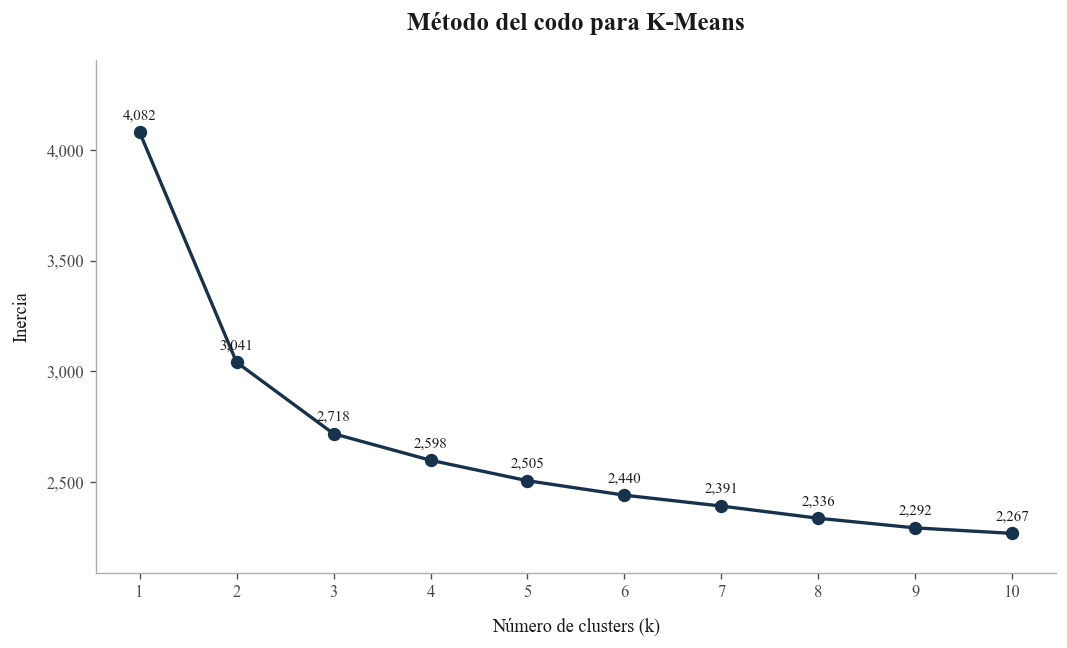

In [8]:
# Visualizamos la inercia obtenida para cada número de clusters
# con el propósito de construir el método del codo (Elbow Method)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de línea.
# En el eje horizontal se representa el número de clusters evaluado
# y en el eje vertical la inercia obtenida por K-Means.
ax.plot(
    resultados_kmeans["Clusters"],
    resultados_kmeans["Inercia"],
    color=AZUL_MARINO,
    marker="o",
    markersize=7,
    linewidth=2
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Método del codo para K-Means",
    pad=18
)

ax.set_xlabel(
    "Número de clusters (k)",
    labelpad=10
)

ax.set_ylabel(
    "Inercia",
    labelpad=10
)

# Indicamos explícitamente todos los valores de k evaluados
# para facilitar la lectura de la gráfica
ax.set_xticks(
    resultados_kmeans["Clusters"]
)

# Aplicamos separadores de miles al eje vertical
# para facilitar la lectura de los valores de inercia
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

# Eliminamos los bordes que no aportan información
# para mantener el mismo estilo visual utilizado en el EDA
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el valor de la inercia junto a cada punto
# para mostrar con claridad el resultado obtenido para cada k
for k, inercia in zip(
    resultados_kmeans["Clusters"],
    resultados_kmeans["Inercia"]
):
    ax.text(
        k,
        inercia + 45,
        f"{inercia:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=NEGRO
    )

# Dejamos un pequeño espacio adicional en la parte superior
# para que las etiquetas no queden pegadas al límite de la figura
ax.set_ylim(
    resultados_kmeans["Inercia"].min() * 0.92,
    resultados_kmeans["Inercia"].max() * 1.08
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "kmeans_metodo_codo"
)

# Mostramos la figura
plt.show()

**Interpretación del método del codo (K-Means)**

La gráfica muestra que la mayor reducción de la inercia ocurre al pasar de **1 a 2 clusters**, disminuyendo de 4,081.88 a 3,041.10. A partir de este punto, la reducción continúa, pero de manera considerablemente menor. Por ello, el método del codo sugiere que **2 clusters constituye una alternativa razonable**, ya que aumentar el número de grupos produce mejoras cada vez más pequeñas en la compactación de las empresas.

### Coeficiente de Silhouette

Como segundo criterio, se comparan los coeficientes de Silhouette obtenidos para las configuraciones de **k = 2 a k = 10**, con el propósito de evaluar la cohesión interna y la separación entre los grupos identificados.

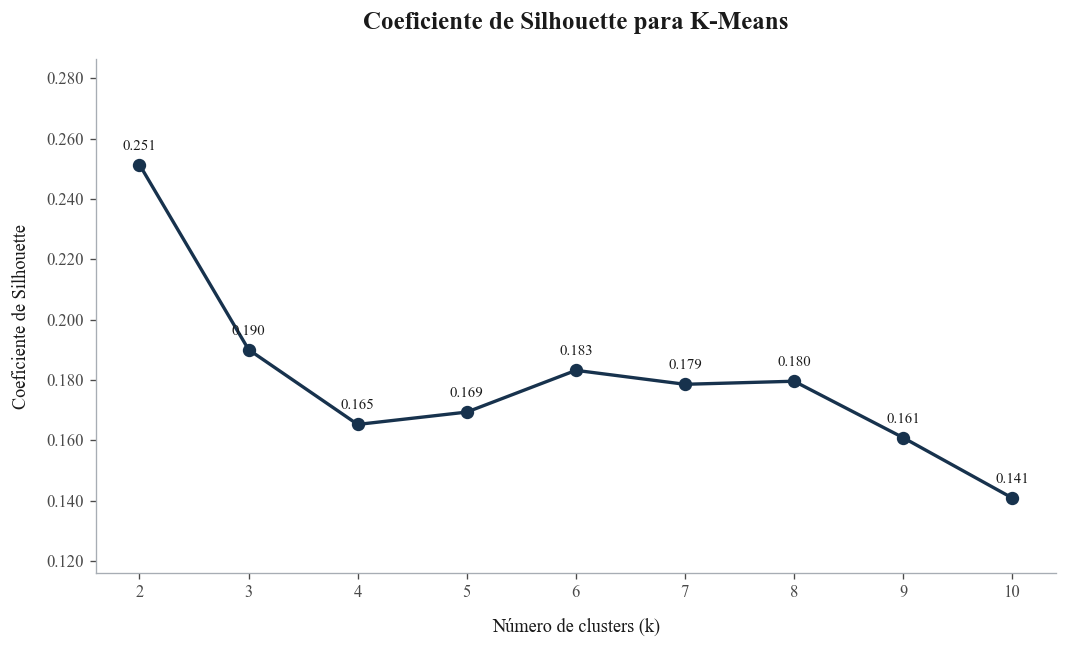

In [9]:
# Preparamos los resultados utilizados en la gráfica de Silhouette.
# Se excluye k = 1 porque el coeficiente requiere
# la existencia de al menos dos clusters.

resultados_silhouette = (
    resultados_kmeans
    .dropna(subset=["Silhouette"])
    .copy()
)

# Visualizamos el coeficiente de Silhouette obtenido
# para cada número de clusters evaluado

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de línea.
# En el eje horizontal se representa el número de clusters
# y en el eje vertical el coeficiente de Silhouette.
ax.plot(
    resultados_silhouette["Clusters"],
    resultados_silhouette["Silhouette"],
    color=AZUL_MARINO,
    marker="o",
    markersize=7,
    linewidth=2
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Coeficiente de Silhouette para K-Means",
    pad=18
)

ax.set_xlabel(
    "Número de clusters (k)",
    labelpad=10
)

ax.set_ylabel(
    "Coeficiente de Silhouette",
    labelpad=10
)

# Indicamos explícitamente los valores de k evaluados
ax.set_xticks(
    resultados_silhouette["Clusters"]
)

# Mostramos tres decimales en el eje vertical
# para facilitar la comparación entre configuraciones
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:.3f}")
)

# Eliminamos los bordes que no aportan información
# manteniendo el mismo formato utilizado en las demás figuras
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el coeficiente obtenido junto a cada punto
# para mostrar con claridad las diferencias entre valores de k
for k, silhouette in zip(
    resultados_silhouette["Clusters"],
    resultados_silhouette["Silhouette"]
):
    ax.text(
        k,
        silhouette + 0.004,
        f"{silhouette:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=NEGRO
    )


# Dejamos un pequeño espacio adicional alrededor de los valores
# para evitar que las etiquetas queden pegadas a los límites
ax.set_ylim(
    resultados_silhouette["Silhouette"].min() - 0.025,
    resultados_silhouette["Silhouette"].max() + 0.035
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "kmeans_coeficiente_silhouette"
)

# Mostramos la figura
plt.show()

**Interpretación del coeficiente de Silhouette (K-Means)**

El coeficiente de Silhouette alcanza su valor más alto con **2 clusters (0.251)**. Para configuraciones con un mayor número de grupos, el coeficiente disminuye y no vuelve a alcanzar este nivel. Esto indica que, entre las configuraciones evaluadas, la solución con **2 clusters presenta la mejor combinación de cohesión interna y separación entre grupos**. Sin embargo, el valor obtenido es moderado, por lo que los grupos no presentan una separación completamente marcada.

**Número de clusters candidato**

En conjunto, tanto el método del codo como el coeficiente de Silhouette señalan a **k = 2** como la configuración más favorable entre las evaluadas. Por esta razón, se selecciona **2 clusters como solución candidata de K-Means**, cuya estabilidad e interpretación serán evaluadas posteriormente antes de determinar el modelo final de agrupamiento.

### Evaluación de la estabilidad de K-Means

Una vez identificado **k = 2** como el número de clusters candidato, se evalúa la estabilidad de esta solución ante distintas inicializaciones del algoritmo. K-Means puede producir resultados diferentes dependiendo de la posición inicial de los centroides, por lo que se repite el agrupamiento utilizando distintas semillas aleatorias.

Para comparar las asignaciones obtenidas se utiliza el **Adjusted Rand Index (ARI)**, que mide el grado de coincidencia entre dos agrupamientos considerando qué empresas permanecen juntas en los mismos grupos. Un valor cercano a **1** indica que ambas soluciones presentan prácticamente la misma estructura de agrupamiento, independientemente del número utilizado para identificar cada cluster.

La solución obtenida con la semilla definida para el análisis se utiliza como referencia y se compara con los resultados generados mediante distintas semillas.

In [10]:
# Evaluamos la estabilidad de la solución candidata de K-Means
# utilizando distintas semillas aleatorias

# Definimos el número de clusters seleccionado como candidato
# a partir del método del codo y del coeficiente de Silhouette
K_CANDIDATO = 2

# Construimos primero una solución de referencia utilizando
# la semilla definida al inicio del notebook
modelo_referencia = KMeans(

    # Utilizamos los dos clusters seleccionados como candidatos
    n_clusters=K_CANDIDATO,

    # Utilizamos la semilla fija del análisis
    random_state=SEMILLA,

    # Ejecutamos K-Means 20 veces con diferentes
    # inicializaciones y conservamos la mejor solución
    n_init=20
)

# Ajustamos el modelo de referencia a los 109 indicadores
# y recuperamos el cluster asignado a cada empresa
etiquetas_referencia = modelo_referencia.fit_predict(X)

# Definimos distintas semillas para comprobar si la estructura
# de los grupos cambia ante diferentes inicializaciones
semillas_estabilidad = [
    1, 5, 10, 15, 20,
    25, 30, 35, 40, 45
]

# Creamos una lista vacía donde almacenaremos
# el resultado correspondiente a cada semilla
resultados_estabilidad = []

# Repetimos K-Means utilizando cada una de las semillas definidas
for semilla in semillas_estabilidad:

    # Construimos un nuevo modelo manteniendo exactamente
    # k = 2 y modificando únicamente la semilla aleatoria
    modelo = KMeans(

        # Mantenemos fijo el número de clusters candidato
        n_clusters=K_CANDIDATO,

        # Cambiamos la semilla en cada repetición
        random_state=semilla,

        # Mantenemos el mismo número de inicializaciones
        # utilizado durante la evaluación anterior
        n_init=20
    )

    # Ajustamos el modelo y recuperamos el cluster
    # asignado a cada una de las 250 empresas
    etiquetas = modelo.fit_predict(X)

    # Calculamos el Adjusted Rand Index (ARI) comparando
    # esta solución con la solución de referencia
    # Un valor cercano a 1 indica que ambas soluciones
    # agrupan a las empresas prácticamente de la misma manera.
    ari = adjusted_rand_score(
        etiquetas_referencia,
        etiquetas
    )

    # Guardamos la semilla utilizada y el nivel
    # de coincidencia obtenido respecto a la referencia
    resultados_estabilidad.append({
        "Semilla": semilla,
        "ARI": ari
    })

# Convertimos los resultados en un DataFrame
# para facilitar su revisión
resultados_estabilidad = pd.DataFrame(
    resultados_estabilidad
)

# Mostramos los resultados de la evaluación de estabilidad
display(resultados_estabilidad)

,Semilla,ARI
0,1,0.984
1,5,0.984
2,10,0.984
3,15,0.968
4,20,1.000
5,25,0.984
6,30,0.984
7,35,0.984
8,40,0.968
9,45,0.968


Los valores del **Adjusted Rand Index (ARI)** obtenidos se encuentran entre **0.968 y 1.000**, lo que indica un nivel muy alto de coincidencia entre las agrupaciones generadas con distintas semillas. En particular, una de las configuraciones reprodujo exactamente la solución de referencia (**ARI = 1.000**), mientras que las demás presentaron valores muy cercanos a 1. Estos resultados muestran que la solución de **K-Means con k = 2 es estable ante diferentes inicializaciones del algoritmo**, por lo que la formación de los dos grupos no depende de manera importante de la semilla utilizada.

### Recuperación de la solución candidata de K-Means

Después de seleccionar **k = 2** como número de clusters candidato y comprobar que la solución es estable ante distintas inicializaciones, se ajusta nuevamente K-Means utilizando la semilla definida para el análisis.

El objetivo de esta etapa es recuperar la asignación correspondiente a la solución candidata de K-Means y conservarla junto con su información descriptiva para realizar posteriormente la interpretación de los perfiles identificados.

In [ ]:
# Ajustamos nuevamente K-Means utilizando
# la configuración candidata seleccionada

# Construimos la solución candidata de K-Means
# con dos clusters
modelo_kmeans_candidato = KMeans(

    # Utilizamos el número de clusters seleccionado
    n_clusters=K_CANDIDATO,

    # Utilizamos la semilla fija definida
    # al inicio del notebook
    random_state=SEMILLA,

    # Ejecutamos el algoritmo 20 veces con diferentes
    # inicializaciones y conservamos la mejor solución
    n_init=20
)

# Ajustamos el modelo a los 109 indicadores binarios
# y recuperamos el cluster asignado a cada empresa
clusters_kmeans = modelo_kmeans_candidato.fit_predict(X)

# Creamos una copia de la información descriptiva
# de las empresas para conservar sus nombres y país de sede
resultado_kmeans = informacion_empresas.copy()

# Incorporamos el cluster asignado por K-Means
# a cada una de las 250 empresas
resultado_kmeans["Cluster_KMeans"] = clusters_kmeans

# Mostramos las primeras observaciones para verificar
# que la asignación se haya incorporado correctamente
display(
    resultado_kmeans.head()
)

,Company,Pais_sede,Cluster_KMeans
0,AJIO,India,1
1,ALDO,Canadá,1
2,Abercrombie & Fitch,Estados Unidos,1
3,Adidas AG,Alemania,0
4,Aeropostale Inc.,Estados Unidos,1


In [12]:
# Revisamos el número de empresas asignadas
# a cada uno de los clusters identificados

distribucion_clusters_kmeans = (
    resultado_kmeans["Cluster_KMeans"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Empresas")
)

display(
    distribucion_clusters_kmeans
)

,Cluster,Empresas
0,0,108
1,1,142


In [13]:
# Exportamos la asignación de clusters obtenida
# para conservarla y utilizarla posteriormente
# durante la interpretación de los perfiles.

resultado_kmeans.to_csv(
    ruta_datos / "resultado_kmeans_clusters.csv",
    index=False
)

print(
    "Resultado de K-Means exportado correctamente."
)

Resultado de K-Means exportado correctamente.


### Interpretación de los perfiles obtenidos con K-Means

Una vez recuperada la asignación de las empresas a los dos clusters, se analizan las características de cada grupo con el propósito de identificar los patrones de divulgación que los distinguen. La interpretación se realiza en distintos niveles: primero se compara el nivel general de divulgación y el tamaño de los grupos; posteriormente se analizan las diferencias entre las categorías **Environment, Social y Governance** y, finalmente, se identifican los indicadores que presentan las mayores diferencias entre ambos clusters. A partir de estos resultados se construye una descripción general de cada perfil de transparencia.


**Distribución y nivel general de divulgación**

In [14]:
# Calculamos el porcentaje general de divulgación de cada empresa

# Como los 109 indicadores están codificados como 0 y 1,
# la media de cada fila representa la proporción de indicadores
# para los que cada empresa divulga información.

porcentaje_divulgacion_empresa = (
    X
    .mean(axis=1)
    .mul(100)
)

# Creamos una copia de la tabla que contiene
# la empresa, su país de sede y el cluster asignado
analisis_perfiles_kmeans = resultado_kmeans.copy()

# Incorporamos el porcentaje general de divulgación
# correspondiente a cada empresa.
analisis_perfiles_kmeans["Porcentaje_divulgacion"] = (
    porcentaje_divulgacion_empresa.values
)

# Calculamos el promedio de divulgación dentro de cada cluster
# y el número de empresas que lo componen
resumen_general_clusters = (
    analisis_perfiles_kmeans
    .groupby(
        "Cluster_KMeans",
        as_index=False
    )
    .agg(
        Empresas=("Company", "nunique"),
        Porcentaje_promedio_divulgacion=(
            "Porcentaje_divulgacion",
            "mean"
        )
    )
)

# Redondeamos el porcentaje para facilitar su lectura
resumen_general_clusters[
    "Porcentaje_promedio_divulgacion"
] = (
    resumen_general_clusters[
        "Porcentaje_promedio_divulgacion"
    ]
    .round(2)
)

# Mostramos el resultado.
display(resumen_general_clusters)

,Cluster_KMeans,Empresas,Porcentaje_promedio_divulgacion
0,0,108,44.510
1,1,142,10.820


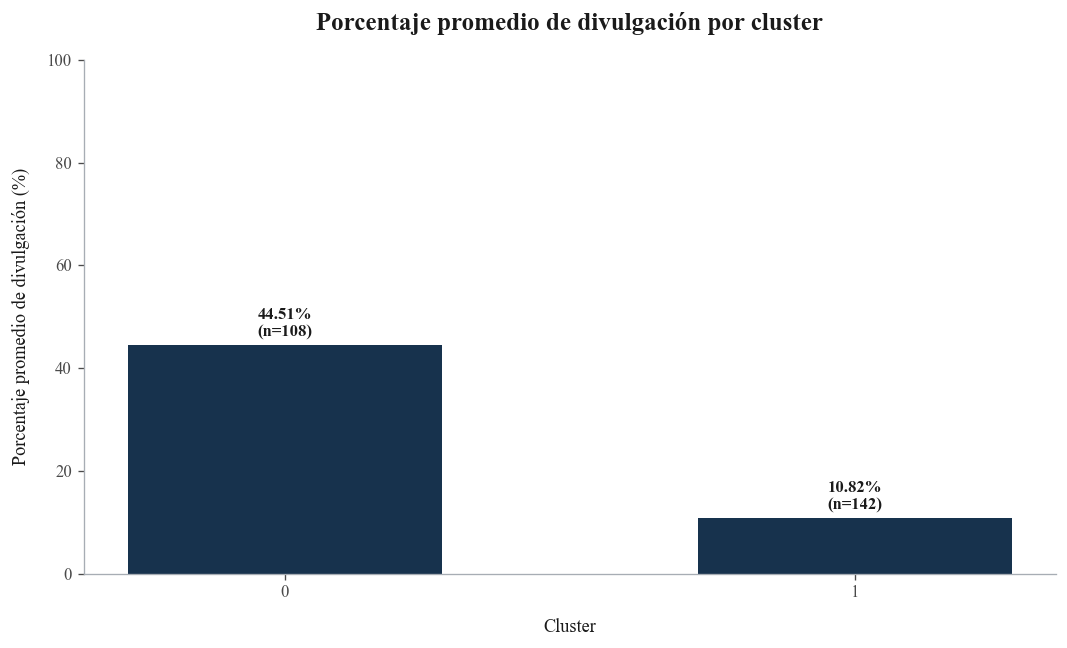

In [15]:
# Visualizamos el porcentaje promedio general de divulgación
# correspondiente a cada cluster identificado por K-Means

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos una gráfica de barras donde cada barra
# representa uno de los dos clusters identificados
barras = ax.bar(
    resumen_general_clusters["Cluster_KMeans"].astype(str),
    resumen_general_clusters["Porcentaje_promedio_divulgacion"],
    color=AZUL_MARINO,
    width=0.55
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por cluster",
    pad=18
)

ax.set_xlabel(
    "Cluster",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
# para conservar el mismo formato visual utilizado
# en las figuras anteriores
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos sobre cada barra el porcentaje promedio
# y el número de empresas que componen el cluster
for barra, porcentaje, empresas in zip(
    barras,
    resumen_general_clusters["Porcentaje_promedio_divulgacion"],
    resumen_general_clusters["Empresas"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{porcentaje:.2f}%\n(n={empresas})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Establecemos el eje vertical entre 0 y 100,
# ya que se representa un porcentaje de divulgación
ax.set_ylim(0, 100)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_divulgacion_promedio_clusters"
)

# Mostramos la figura
plt.show()

El **Cluster 0**, integrado por 108 empresas, presenta un porcentaje promedio general de divulgación de **44.51%**, mientras que el **Cluster 1**, compuesto por 142 empresas, registra un promedio de **10.82%**. La diferencia de **33.69 puntos porcentuales** indica que K-Means separa principalmente a las empresas en un grupo con mayor divulgación y otro con menor divulgación. Para conocer si esta diferencia se mantiene de la misma manera en todas las categorías temáticas, a continuación se comparan los perfiles de **Environment, Social y Governance**.

**Perfil de divulgación por categoría temática**

Para comprender con mayor detalle las diferencias entre los perfiles identificados, se compara el porcentaje promedio de divulgación de cada cluster en las categorías **Environment, Social y Governance**. Este análisis permite determinar si la separación observada entre los grupos responde únicamente a una diferencia general en el nivel de divulgación o si existen patrones distintos entre las categorías temáticas.

In [16]:
# Cargamos el diccionario de indicadores para recuperar
# la categoría temática correspondiente a cada variable

diccionario_indicadores = pd.read_excel(
    ruta_datos / "diccionario_indicadores.xlsx"
)

# Conservamos únicamente la información necesaria:
# el nombre original del indicador y su categoría temática
categorias_indicadores = (
    diccionario_indicadores[
        ["Indicador original", "Categoría temática"]
    ]
    .drop_duplicates()
)

# Creamos un diccionario que relaciona cada indicador
# con su categoría temática
mapa_categorias = dict(
    zip(
        categorias_indicadores["Indicador original"],
        categorias_indicadores["Categoría temática"]
    )
)

# Verificamos que todos los indicadores utilizados en X
# tengan una categoría temática asignada
indicadores_sin_categoria = [
    indicador
    for indicador in X.columns
    if indicador not in mapa_categorias
]

print(
    "Indicadores sin categoría temática:",
    len(indicadores_sin_categoria)
)

# Creamos una copia de la matriz de indicadores
# e incorporamos el cluster asignado a cada empresa
X_clusters = X.copy()

X_clusters["Cluster_KMeans"] = clusters_kmeans

# Transformamos la matriz de formato ancho a formato largo
# De esta manera, cada fila representa la combinación:
# empresa - indicador - cluster
X_largo = (
    X_clusters
    .reset_index()
    .melt(
        id_vars=["index", "Cluster_KMeans"],
        var_name="Indicador",
        value_name="Divulga"
    )
)

# Incorporamos la categoría temática correspondiente
# a cada indicador
X_largo["Categoria"] = (
    X_largo["Indicador"]
    .map(mapa_categorias)
)

# Conservamos únicamente las tres categorías utilizadas
# para la interpretación de los perfiles
X_largo_esg = X_largo[
    X_largo["Categoria"].isin(
        ["Environment", "Social", "Governance"]
    )
].copy()

# Calculamos el porcentaje promedio de divulgación
# de cada cluster dentro de cada categoría temática
perfil_categorias_kmeans = (
    X_largo_esg
    .groupby(
        ["Cluster_KMeans", "Categoria"],
        as_index=False
    )
    ["Divulga"]
    .mean()
)

# Convertimos las proporciones a porcentajes
perfil_categorias_kmeans[
    "Porcentaje_divulgacion"
] = (
    perfil_categorias_kmeans["Divulga"]
    .mul(100)
    .round(2)
)

# Conservamos únicamente las columnas necesarias
# para presentar los resultados
perfil_categorias_kmeans = (
    perfil_categorias_kmeans[
        [
            "Cluster_KMeans",
            "Categoria",
            "Porcentaje_divulgacion"
        ]
    ]
)

# Mostramos los resultados
display(perfil_categorias_kmeans)

Indicadores sin categoría temática: 0


,Cluster_KMeans,Categoria,Porcentaje_divulgacion
0,0,Environment,46.950
1,0,Governance,50.740
2,0,Social,39.830
3,1,Environment,9.960
4,1,Governance,14.960
5,1,Social,9.820


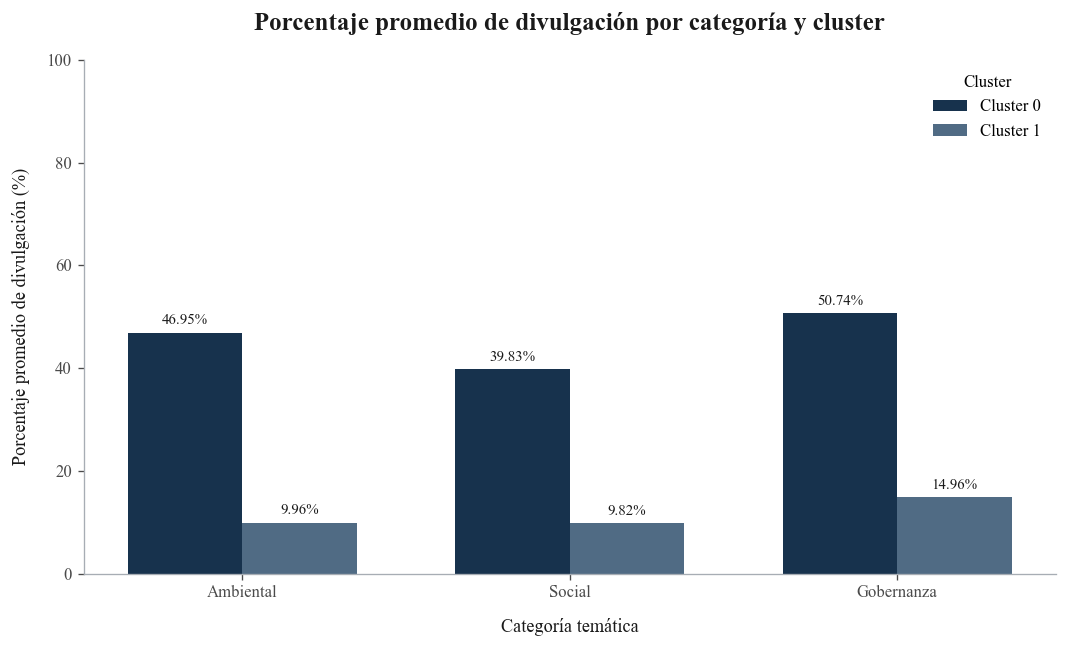

In [17]:
# Visualizamos el porcentaje promedio de divulgación
# de cada cluster por categoría temática

# Reorganizamos la tabla para facilitar la construcción
# de una gráfica de barras agrupadas
perfil_grafica = (
    perfil_categorias_kmeans
    .pivot(
        index="Categoria",
        columns="Cluster_KMeans",
        values="Porcentaje_divulgacion"
    )
    .loc[
        ["Environment", "Social", "Governance"]
    ]
)

# Definimos las posiciones de las categorías
posiciones = np.arange(
    len(perfil_grafica.index)
)

# Definimos el ancho de las barras
ancho = 0.35


# Construimos la figura
fig, ax = plt.subplots(figsize=(9, 5.5))

# Graficamos los valores correspondientes al Cluster 0
barras_0 = ax.bar(
    posiciones - ancho / 2,
    perfil_grafica[0],
    width=ancho,
    color=AZUL_MARINO,
    label="Cluster 0"
)

# Graficamos los valores correspondientes al Cluster 1
barras_1 = ax.bar(
    posiciones + ancho / 2,
    perfil_grafica[1],
    width=ancho,
    color=AZUL_SECUNDARIO,
    label="Cluster 1"
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por categoría y cluster",
    pad=18
)

ax.set_xlabel(
    "Categoría temática",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Incorporamos los nombres de las categorías
# utilizando su traducción al español
ax.set_xticks(posiciones)

ax.set_xticklabels(
    ["Ambiental", "Social", "Gobernanza"]
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barras in [barras_0, barras_1]:
    for barra in barras:
        valor = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1,
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            color=NEGRO
        )

# Establecemos el eje vertical entre 0 y 100
# porque los valores representan porcentajes
ax.set_ylim(0, 100)

# Incorporamos la leyenda
ax.legend(
    frameon=False,
    title="Cluster"
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_perfil_categorias_clusters"
)

# Mostramos la figura
plt.show()

El **Cluster 0** presenta mayores niveles promedio de divulgación en las tres categorías analizadas: **50.74% en Gobernanza, 46.95% en Ambiental y 39.83% en Social**. El **Cluster 1** registra niveles considerablemente menores: **14.96%, 9.96% y 9.82%**, respectivamente. En ambos grupos, Gobernanza presenta el mayor nivel de divulgación, mientras que Social se encuentra entre las categorías con menor divulgación. Por lo tanto, los resultados muestran que la principal diferencia entre los clusters se encuentra en el **nivel general de divulgación**, más que en perfiles temáticos opuestos entre las categorías.

**Indicadores que más diferencian los perfiles**

Después de comparar los niveles generales y las categorías temáticas, se analizan los **109 indicadores individuales** utilizados en el agrupamiento. El objetivo es identificar en qué indicadores existe una mayor diferencia en el porcentaje de divulgación entre los dos clusters y, por lo tanto, cuáles contribuyen a caracterizar con mayor claridad los perfiles obtenidos.

In [18]:
# Calculamos el porcentaje de divulgación de cada indicador
# dentro de cada uno de los clusters identificados por K-Means

# Creamos una copia de la matriz de indicadores
# para incorporar la asignación de cluster de cada empresa
perfil_indicadores_kmeans = X.copy()

# Añadimos el cluster correspondiente a cada empresa
perfil_indicadores_kmeans["Cluster_KMeans"] = (
    clusters_kmeans
)

# Calculamos la media de cada indicador dentro de cada cluster
# Debido a que los indicadores están codificados como 0 y 1,
# la media representa la proporción de empresas del cluster
# que divulga la información correspondiente.
promedio_indicadores_cluster = (
    perfil_indicadores_kmeans
    .groupby("Cluster_KMeans")
    .mean()
    .T
    .mul(100)
    .reset_index()
)

# Renombramos las columnas para facilitar su interpretación.
promedio_indicadores_cluster.columns = [
    "Indicador",
    "Cluster_0",
    "Cluster_1"
]

# Incorporamos la categoría temática correspondiente
# a cada indicador utilizando el diccionario construido previamente.
promedio_indicadores_cluster["Categoria"] = (
    promedio_indicadores_cluster["Indicador"]
    .map(mapa_categorias)
)

# Calculamos la diferencia, en puntos porcentuales,
# entre el porcentaje de divulgación del Cluster 0
# y el porcentaje de divulgación del Cluster 1.

# Un valor positivo indica mayor divulgación en el Cluster 0
# Un valor negativo indicaría mayor divulgación en el Cluster 1
promedio_indicadores_cluster["Diferencia_pp"] = (
    promedio_indicadores_cluster["Cluster_0"]
    -
    promedio_indicadores_cluster["Cluster_1"]
)

# Calculamos también la diferencia absoluta
# Esto permite ordenar los indicadores únicamente por el tamaño
# de la diferencia entre clusters, independientemente de cuál
# de los dos presenta el porcentaje más alto.
promedio_indicadores_cluster["Diferencia_absoluta_pp"] = (
    promedio_indicadores_cluster["Diferencia_pp"]
    .abs()
)

# Ordenamos los indicadores desde la mayor
# hasta la menor diferencia entre clusters
promedio_indicadores_cluster = (
    promedio_indicadores_cluster
    .sort_values(
        "Diferencia_absoluta_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

# Redondeamos los porcentajes y las diferencias
# para facilitar la presentación de los resultados
columnas_redondear = [
    "Cluster_0",
    "Cluster_1",
    "Diferencia_pp",
    "Diferencia_absoluta_pp"
]

promedio_indicadores_cluster[
    columnas_redondear
] = (
    promedio_indicadores_cluster[
        columnas_redondear
    ]
    .round(2)
)

# Mostramos los diez indicadores con mayor diferencia
# entre los dos perfiles identificados
top_10_diferencias_kmeans = (
    promedio_indicadores_cluster
    .head(10)
    .copy()
)

display(
    top_10_diferencias_kmeans[
        [
            "Indicador",
            "Categoria",
            "Cluster_0",
            "Cluster_1",
            "Diferencia_pp"
        ]
    ]
)

,Indicador,Categoria,Cluster_0,Cluster_1,Diferencia_pp
0,Fashion Revolution+Targets to Reduce Virgin Pl...,Environment,86.110,16.200,69.910
1,Fashion Revolution+Describes Environmental Due...,Environment,88.890,19.010,69.870
2,"Fashion Revolution+Scope, Process and Accredit...",Environment,81.480,14.790,66.690
3,Fashion Revolution+Plan for Improving Human Ri...,Social,84.260,18.310,65.950
4,Fashion Revolution+Human Rights Risks Impacts ...,Social,89.810,23.940,65.870
5,Fashion Revolution+Environmental Risks Impacts...,Governance,74.070,9.150,64.920
6,Fashion Revolution+Reports on Efforts to Impro...,Social,76.850,11.970,64.880
7,Fashion Revolution+Discloses Progress on Susta...,Environment,78.700,14.790,63.910
8,Fashion Revolution+Prevention Mitigation and R...,Social,69.440,8.450,60.990
9,Fashion Revolution+Discloses Evidence of Devel...,Environment,72.220,11.270,60.950


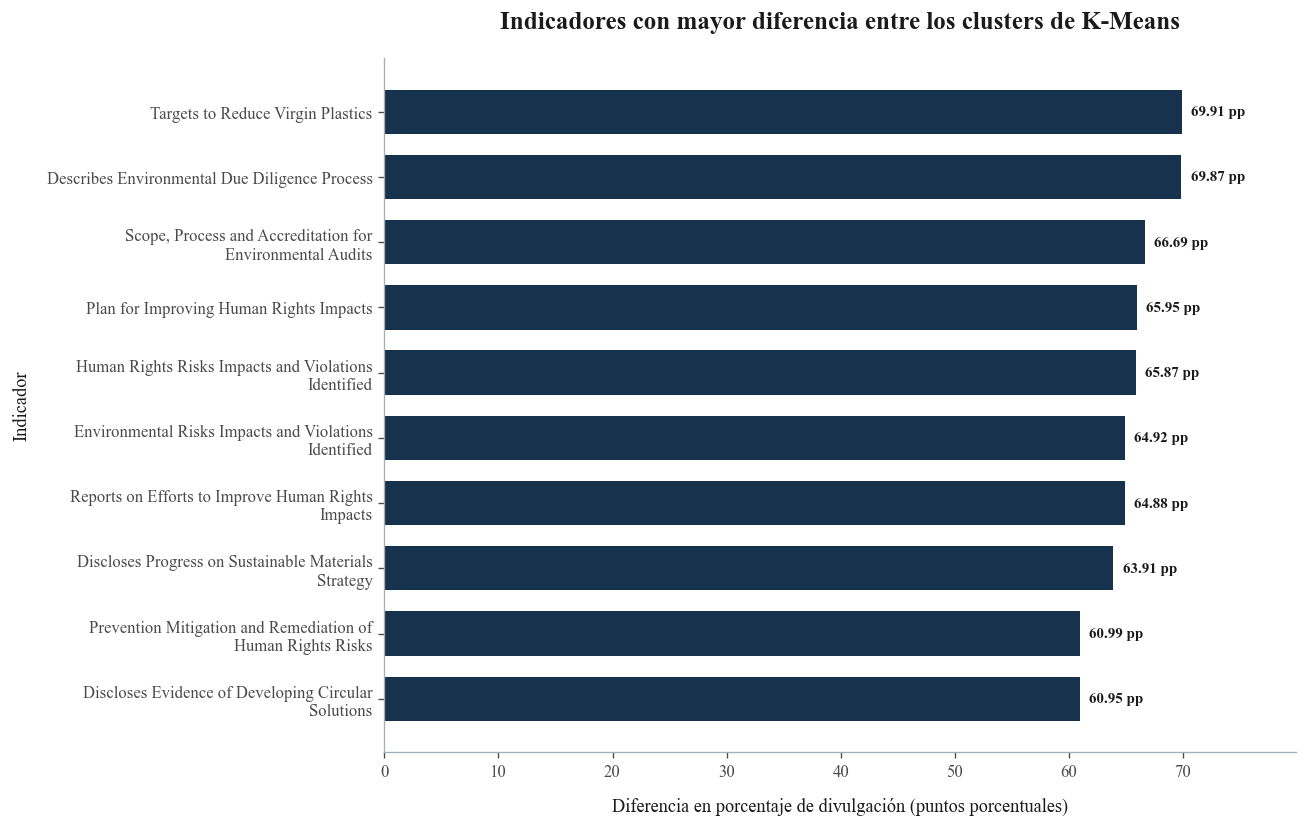

In [19]:
# Visualizamos los diez indicadores con mayor diferencia
# en el porcentaje de divulgación entre los clusters de K-Means

# Creamos una copia para preparar la información
# que será utilizada únicamente en la figura
top_10_grafica_kmeans = top_10_diferencias_kmeans.copy()

# Eliminamos el prefijo "Fashion Revolution+"
# para hacer más legibles los nombres de los indicadores
top_10_grafica_kmeans["Indicador_visual"] = (
    top_10_grafica_kmeans["Indicador"]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)

# Dividimos automáticamente los nombres largos
# en varias líneas para facilitar su lectura
top_10_grafica_kmeans["Indicador_visual"] = (
    top_10_grafica_kmeans["Indicador_visual"]
    .apply(
        lambda texto: textwrap.fill(
            texto,
            width=45
        )
    )
)

# Ordenamos los indicadores de menor a mayor diferencia
# para que el valor más alto aparezca en la parte superior
top_10_grafica_kmeans = (
    top_10_grafica_kmeans
    .sort_values(
        "Diferencia_pp",
        ascending=True
    )
)

# Construimos la figura
fig, ax = plt.subplots(figsize=(11, 7))

# Construimos una gráfica horizontal utilizando
# la diferencia en puntos porcentuales entre ambos clusters
barras = ax.barh(
    top_10_grafica_kmeans["Indicador_visual"],
    top_10_grafica_kmeans["Diferencia_pp"],
    color=AZUL_MARINO,
    height=0.68
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Indicadores con mayor diferencia entre los clusters de K-Means",
    pad=18
)

ax.set_xlabel(
    "Diferencia en porcentaje de divulgación (puntos porcentuales)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
# para mantener el mismo formato visual del análisis
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el valor de la diferencia al final de cada barra
for barra, diferencia in zip(
    barras,
    top_10_grafica_kmeans["Diferencia_pp"]
):
    ax.text(
        diferencia + 0.8,
        barra.get_y() + barra.get_height() / 2,
        f"{diferencia:.2f} pp",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio adicional para mostrar
# las etiquetas al final de las barras
ax.set_xlim(
    0,
    top_10_grafica_kmeans["Diferencia_pp"].max() + 10
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "kmeans_top_10_diferencias_indicadores"
)

# Mostramos la figura
plt.show()

Los indicadores que presentan las mayores diferencias entre los clusters muestran brechas de aproximadamente **61 a 70 puntos porcentuales**. Las diferencias más amplias corresponden a *Targets to Reduce Virgin Plastics* (metas para reducir el uso de plásticos vírgenes), *Describes Environmental Due Diligence Process* (describe el proceso de debida diligencia ambiental), *Scope, Process and Accreditation for Environmental Audits* (alcance, proceso y acreditación de auditorías ambientales), *Plan for Improving Human Rights Impacts* (plan para mejorar los impactos en derechos humanos) y *Human Rights Risks Impacts and Violations Identified* (riesgos, impactos y violaciones de derechos humanos identificados). También destacan *Environmental Risks Impacts and Violations Identified* (riesgos, impactos y violaciones ambientales identificados), *Reports on Efforts to Improve Human Rights Impacts* (reporta esfuerzos para mejorar los impactos en derechos humanos), *Discloses Progress on Sustainable Materials Strategy* (divulga avances en la estrategia de materiales sostenibles), *Prevention Mitigation and Remediation of Human Rights Risks* (prevención, mitigación y remediación de riesgos de derechos humanos) y *Discloses Evidence of Developing Circular Solutions* (divulga evidencia del desarrollo de soluciones circulares).

En todos estos indicadores, el porcentaje de divulgación es considerablemente mayor en el **Cluster 0**.

In [21]:
# Verificamos si existe algún indicador en el que
# el Cluster 1 presente mayor divulgación que el Cluster 0

indicadores_mayor_cluster_1 = (
    promedio_indicadores_cluster[
        promedio_indicadores_cluster["Diferencia_pp"] < 0
    ]
    .sort_values("Diferencia_pp")
)

print(
    "Indicadores con mayor divulgación en el Cluster 1:",
    len(indicadores_mayor_cluster_1)
)

Indicadores con mayor divulgación en el Cluster 1: 0


**No se identificó ningún indicador entre los 109 analizados en el que el Cluster 1 presentara un porcentaje de divulgación superior al Cluster 0**. Este resultado refuerza la interpretación de que la separación obtenida mediante K-Means responde principalmente al **nivel general de divulgación**.

**Empresas más representativas de cada perfil**

Como complemento a la caracterización de los clusters, se identifican las **empresas cuyo patrón de divulgación se encuentra más cercano al centroide de cada grupo**. Debido a que el centroide representa el patrón promedio de los indicadores dentro de un cluster, las empresas con menor distancia pueden considerarse ejemplos representativos del perfil identificado.

Esta medida no indica que una empresa tenga un mejor desempeño o un mayor nivel de transparencia, sino únicamente que **su patrón de respuestas es más similar al perfil promedio del cluster** al que pertenece.

In [22]:
# Identificamos las empresas más representativas
# de cada uno de los clusters obtenidos mediante K-Means

# Calculamos la distancia de cada empresa
# a cada uno de los dos centroides del modelo

# El resultado contiene una distancia para el Cluster 0
# y otra para el Cluster 1 por cada empresa
distancias_centroides = (
    modelo_kmeans_candidato
    .transform(X)
)

# Recuperamos, para cada empresa, únicamente la distancia
# al centroide del cluster al que fue asignada

# Una distancia menor indica que el patrón de divulgación
# de la empresa se parece más al patrón promedio de su cluster.
distancia_cluster_asignado = (
    distancias_centroides[
        np.arange(len(X)),
        clusters_kmeans
    ]
)

# Utilizamos la tabla construida previamente,
# que ya contiene el nombre de la empresa,
# su país, el cluster y su porcentaje de divulgación
empresas_representativas_kmeans = (
    analisis_perfiles_kmeans
    .copy()
)

# Incorporamos la distancia de cada empresa
# al centroide de su propio cluster
empresas_representativas_kmeans[
    "Distancia_centroide"
] = (
    distancia_cluster_asignado
)

# Ordenamos primero por cluster y después
# por distancia de menor a mayor
# De esta manera, las empresas más cercanas
# al centroide aparecen primero dentro de cada grupo
empresas_representativas_kmeans = (
    empresas_representativas_kmeans
    .sort_values(
        [
            "Cluster_KMeans",
            "Distancia_centroide"
        ],
        ascending=[
            True,
            True
        ]
    )
)

# Seleccionamos las cinco empresas con menor distancia
# al centroide dentro de cada cluster
top_5_representativas_kmeans = (
    empresas_representativas_kmeans
    .groupby(
        "Cluster_KMeans",
        as_index=False,
        group_keys=False
    )
    .head(5)
    .copy()
)

# Redondeamos las variables numéricas
# para facilitar la lectura de la tabla
top_5_representativas_kmeans[
    "Porcentaje_divulgacion"
] = (
    top_5_representativas_kmeans[
        "Porcentaje_divulgacion"
    ]
    .round(2)
)

top_5_representativas_kmeans[
    "Distancia_centroide"
] = (
    top_5_representativas_kmeans[
        "Distancia_centroide"
    ]
    .round(3)
)

# Mostramos las empresas más representativas
# de cada uno de los dos perfiles.
display(
    top_5_representativas_kmeans[
        [
            "Cluster_KMeans",
            "Company",
            "Pais_sede",
            "Porcentaje_divulgacion",
            "Distancia_centroide"
        ]
    ]
)

,Cluster_KMeans,Company,Pais_sede,Porcentaje_divulgacion,Distancia_centroide
238,0,Vans,Estados Unidos,55.050,3.373
18,0,Banana Republic,Estados Unidos,50.460,3.378
91,0,Gap inc.,Estados Unidos,50.460,3.378
168,0,Old Navy,Estados Unidos,50.460,3.378
218,0,The North Face Inc.,Estados Unidos,55.960,3.389
62,1,Deichmann SE,Alemania,0.920,1.793
59,1,DKNY,Estados Unidos,0.920,1.808
164,1,Nine West,Estados Unidos,0.920,1.808
66,1,"Dillard's, Inc.",Estados Unidos,2.750,1.812
148,1,Max Fashion,Emiratos Árabes Unidos,0.920,1.832


Las empresas más representativas del **Cluster 0** son *Vans, Banana Republic, Gap Inc., Old Navy* y *The North Face Inc.*, todas con sede en **Estados Unidos** y con porcentajes generales de divulgación de aproximadamente **50% a 56%**. Estas empresas presentan los patrones de respuestas más cercanos al centroide del perfil de mayor divulgación.

En el **Cluster 1**, las empresas más representativas son *Deichmann SE, DKNY, Nine West, Dillard's Inc.* y *Max Fashion*, con sede en **Alemania, Estados Unidos y Emiratos Árabes Unidos**. Sus porcentajes generales de divulgación son considerablemente menores, entre **0.92% y 2.75%**, y sus patrones son los más cercanos al centroide del perfil de menor divulgación.

La presencia de empresas estadounidenses entre los casos más representativos de **ambos clusters** muestra que el país de sede, por sí solo, **no determina la pertenencia a un perfil**. La separación realizada por K-Means responde principalmente a los patrones de divulgación observados en los 109 indicadores: el Cluster 0 reúne empresas con una divulgación considerablemente mayor, mientras que el Cluster 1 concentra empresas con patrones de divulgación mucho más limitados.

### Conclusión de los perfiles identificados con K-Means

A partir de los resultados obtenidos, los dos clusters pueden interpretarse principalmente como perfiles diferenciados por su **nivel general de divulgación**.

El **Cluster 0**, integrado por **108 empresas**, se identifica como un **perfil de mayor divulgación**. Las empresas pertenecientes a este grupo presentan un porcentaje promedio general de divulgación de **44.51%** y registran niveles superiores en las tres categorías analizadas: **50.74% en Gobernanza, 46.95% en Ambiental y 39.83% en Social**. Las mayores diferencias respecto al otro cluster se observan en indicadores relacionados con la **evaluación y gestión de riesgos ambientales y de derechos humanos**, la identificación de impactos, los planes de mejora y las acciones para prevenir o corregir estos riesgos.

El **Cluster 1**, compuesto por **142 empresas**, corresponde a un **perfil de menor divulgación**. Su porcentaje promedio general es de **10.82%**, con niveles de **14.96% en Gobernanza, 9.96% en Ambiental y 9.82% en Social**. Además, no se identificó ningún indicador en el que este grupo presentara un porcentaje de divulgación superior al Cluster 0.

En conjunto, K-Means identifica dos perfiles diferenciados principalmente por la **intensidad de la divulgación**, más que por especializaciones temáticas opuestas. El Cluster 0 concentra empresas que divulgan información con mayor frecuencia de manera generalizada, mientras que el Cluster 1 reúne empresas con niveles considerablemente menores de divulgación en las distintas dimensiones analizadas. La presencia de empresas con sede en **Estados Unidos entre los casos más representativos de ambos clusters** muestra que, al menos entre estos ejemplos, un mismo país puede estar representado en perfiles de divulgación diferentes.
